# NumPy Practice Notebook

A hands-on walkthrough of NumPy — from array basics to broadcasting, linear algebra, random sampling, vectorization, and image processing with SciPy. Each section pairs a short explanation with runnable code, so this works as a learning path or as a quick reference.

**Covered in this notebook:**
- Array creation & dimensions
- Indexing & slicing
- Reshaping, resizing, stacking & splitting
- Broadcasting
- Matrix operations & linear algebra (multiplication, inner/outer/cross products, determinant, inverse, eigenvalues)
- Random sampling & distributions (random integers, normal, binomial, Poisson, uniform)
- Descriptive statistics, vectorization & performance
- Sparse matrices
- Image processing with NumPy & SciPy

## Array Creation & Dimensions

NumPy's core object is the `ndarray`. Unlike a plain Python list, it stores same-typed elements in a fixed grid, which is what makes it fast. We start by converting a regular list into an array with `np.array()` and comparing it to the list it came from — including `.ndim`, which tells you how many axes (dimensions) the array has.

In [ ]:
import numpy as np
x = [1 , 2 , 3 , 4 , 5]
y = np.array(x)
print(y)
print(type(x))
print(type(y))
print(y.ndim)


[1 2 3 4 5]
<class 'list'>
<class 'numpy.ndarray'>
1


A 2D array — rows and columns, like a small table — is created the same way, just by nesting one list inside another.

In [ ]:
ar2 = np.array([[1 , 2 , 3] , [4 , 5 , 6 ]])
print(ar2)
print(ar2.ndim)
print(type(ar2))

[[1 2 3]
 [4 5 6]]
2
<class 'numpy.ndarray'>


Nesting one level further gives a 3D array. `.shape` reports the size along each axis; `(1, 3, 3)` below means 1 block containing a 3×3 grid.

In [ ]:
ar3 = np.array([[[1 , 2 , 3] , [4 , 5 , 6] , [7 , 8 , 9]]])
print(ar3)
print(ar3.ndim)
print(ar3.shape)


[[[1 2 3]
  [4 5 6]
  [7 8 9]]]
3
(1, 3, 3)


### Forcing a minimum number of dimensions

The `ndmin` parameter pads an array with extra dimensions until it has at least that many — here a plain 1D array of 3 elements becomes 5-dimensional.

In [ ]:

arr = np.array([1, 2, 3], ndmin = 5)

print(arr.ndim)
print(arr)

5
[[[[[1 2 3]]]]]


### `np.empty()` — allocate without initializing

`np.empty()` creates an array of the given shape without setting its values, so it's faster than `np.zeros()` when you're about to overwrite every element anyway. The trade-off: it holds whatever bytes were already in that memory, so treat the values below as garbage, not real data.

In [ ]:
ar_em = np.empty([3, 2], dtype = int)
print(ar_em)

[[1637447216        511]
 [1637447312        511]
 [1981833504  544695657]]


### `np.arange()` — generate a sequence

`np.arange(n)` is NumPy's version of Python's `range()` — evenly spaced values, returned as an array you can use directly in vectorized operations.

In [ ]:
ar_rn = np.arange(6)
print(ar_rn)

[0 1 2 3 4 5]


## Indexing & Slicing

Arrays support the same `start:stop` slicing as Python lists. `arr[1:5]` below returns indices 1 through 4 — the stop index is exclusive.

In [ ]:
arr = np.array([0 , 1 , 2 , 3 , 4 , 5])
arrnew = arr[ 1 : 5]
print(arrnew)

[1 2 3 4]


### Identity matrix with `np.eye()`

`np.eye(N, M)` builds a matrix with 1s on the diagonal and 0s everywhere else — a building block you'll see throughout linear algebra.

In [ ]:
ar_dia = np.eye(3 , 3)
print(ar_dia)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


### Slicing 2D arrays

For 2D arrays, slice each axis separately, separated by a comma: `arr[rows, columns]`. `mat[0:2, 1:3]` below takes rows 0–1 and columns 1–2.

In [ ]:
mat = np.array([[1 , 2 , 3] , [4 , 5 , 6] , [7 , 8 , 9]])
print(mat[0:2 , 1:3])
print(mat[1:3, 0:2])

[[2 3]
 [5 6]]
[[4 5]
 [7 8]]


### Boolean (conditional) indexing

An array can be indexed with a condition instead of positions. `arr[(arr > 20) & (arr < 30)]` keeps only the elements where both conditions hold — no loop needed.

In [ ]:
arr = np.array([10, 15, 20, 25, 30])
print(arr[(arr>20) &(arr<30)])

[25]


One more 2D slicing example — this one pulls the top-left 2×2 corner out of a 3×3 array.

In [ ]:
arr = np.array([[1, 2, 3], 
               [25,30,35] , 
               [40,45,50]])
print(arr)
res = arr[:2 , :2]
print(res)


[[ 1  2  3]
 [25 30 35]
 [40 45 50]]
[[ 1  2]
 [25 30]]


### Slicing 3D arrays

The same comma-separated syntax extends to 3D: `arr[:, :2, :2]` keeps every block along the first axis, and just the top-left 2×2 of each one.

In [ ]:
arr = np.array([[[10, 25, 70], [30, 45, 55], [20, 45, 7]], [[50, 65, 8], [70, 85, 10], [11, 22, 33]]])
print("Array:")
print(arr)

res = arr[: , :2 , :2] 
print("Accessed Rows:")
print(res)


Array:
[[[10 25 70]
  [30 45 55]
  [20 45  7]]

 [[50 65  8]
  [70 85 10]
  [11 22 33]]]
Accessed Rows:
[[[10 25]
  [30 45]]

 [[50 65]
  [70 85]]]


## Shape

`.shape` returns a tuple with the array's size along each dimension — how many rows, columns, and so on. It's one of the most-used attributes for sanity-checking an array before you operate on it.

In [ ]:
var = np.array([[1,2 , 3 , 4] , [1,2 , 3 , 4]])
print(var)
print(var.shape)

[[1 2 3 4]
 [1 2 3 4]]
(2, 4)


In [ ]:
var1 = np.array([1, 2 , 3 , 4] , ndmin = 4)
print(var1)
print(var1.ndim)
print(var1.shape)


[[[[1 2 3 4]]]]
4
(1, 1, 1, 4)
int32


## Reshape

`.reshape()` changes an array's shape without changing its data or total number of elements — the sizes must still multiply out to the same total. Passing `-1` for one dimension tells NumPy to work it out automatically, and `order='F'` reshapes in column-major (Fortran-style) order instead of the default row-major order.

In [ ]:
import numpy as np
var2 = np.array([1, 2 , 3 , 4 , 5 , 6] )
print(var2)
print(var2.ndim)
x = var2.reshape(3, 2 )
print(x)
print(x.ndim)

[1 2 3 4 5 6]
1
[[1 2]
 [3 4]
 [5 6]]
2


In [ ]:
arr = np.array([1, 2, 3, 4, 5, 6])
vaar2 = arr.reshape(2, 3)
print(vaar2)

[[1 2 3]
 [4 5 6]]


In [ ]:
a = np.arange(1 , 9)
print(a)
r = a.reshape(4 , 2)
print(r)

[1 2 3 4 5 6 7 8]
[[1 2]
 [3 4]
 [5 6]
 [7 8]]


In [ ]:
a = np.arange( 12 )
print(a)

b = a.reshape(3 , -1)
print(b)

[ 0  1  2  3  4  5  6  7  8  9 10 11]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [ ]:
a= np.array([1 , 2 , 3 , 4 , 5 , 6])
r = a.reshape(2 ,3 , order = 'F')
print(r)

[[1 3 5]
 [2 4 6]]


Resizing Numpy
numpy.resize() function is used to change the size of an existing NumPy array. It modifies the array permanently and adjusts its shape to the new dimensions. If the new shape requires more elements than available, NumPy repeats the array elements. If less space is required, elements are truncated.

In [ ]:
arr = np.array([1 , 2 , 3 , 4 , 5 , 6])
arr.resize(2 , 3)
print(arr)


[[1 2 3]
 [4 5 6]]


Syntax
numpy.resize(a, new_shape)
Parameters:

a: Input array to be resized.
new_shape: Target shape (int or tuple).
refcheck(optional): If True, checks whether the array is referenced elsewhere before resizing.
Example 2: This example resizes a 6-element array into a 3×4 shape (12 elements needed). NumPy repeats the array elements to fill the new size.

In [ ]:
import numpy as np
arr = np.array([1, 2, 3, 4, 5, 6])
arr.resize((3, 4))
print(arr)

[[1 2 3 4]
 [5 6 0 0]
 [0 0 0 0]]


Example 3: This example resizes an array into a 2×2 shape. Since fewer elements are required, the extra values are removed.






In [ ]:
arr = np.array([10, 20, 30, 40, 50])
arr.resize((2,2))
print(arr)

[[10 20]
 [30 40]]


Stacking
numpy.stack() in Python

The numpy.stack() function is used to join multiple arrays by creating a new axis in the output array

This means the resulting array always has one extra dimension compared to the input arrays.

to stack arrays, they must have the same shape, and NumPy places them along the axis you specify.

Syntax
numpy.stack(arrays, axis=0, out=None)
Parameters:

arrays: Sequence of input arrays with the same shape.
axis: Position of the new axis where arrays will be stacked (default: 0).
out(Optional): output array to store the result.

Example: This example stacks two 1D arrays along a new axis to form a 2D array.

In [ ]:
a= np.array([1,2 ,3])
b = np.array([4,5 ,6])
res = np.stack((a,b) , axis = 0)
res2 = np.stack((a,b) , axis = 1)
res3 = np.stack((a,b) , axis = -1)


print(res)
print(res2)
print(res3)

[[1 2 3]
 [4 5 6]]
[[1 4]
 [2 5]
 [3 6]]
[[1 4]
 [2 5]
 [3 6]]


In [ ]:
import numpy as np

x = np.array([[1, 2, 3],
              [4, 5, 6]])

y = np.array([[7, 8, 9],
              [10, 11, 12]])

print(np.stack((x, y), axis=0))
print(np.stack((x, y), axis=1))
print(np.stack((x, y), axis=2))

[[[ 1  2  3]
  [ 4  5  6]]

 [[ 7  8  9]
  [10 11 12]]]
[[[ 1  2  3]
  [ 7  8  9]]

 [[ 4  5  6]
  [10 11 12]]]
[[[ 1  7]
  [ 2  8]
  [ 3  9]]

 [[ 4 10]
  [ 5 11]
  [ 6 12]]]


NumPy Array Splitting

Splitting = taking one big array and dividing it into smaller arrays.

Think of it like cutting a pizza 🍕 into pieces.

There are mainly 5 functions in your notes:
| Function           | What it does                          |
| ------------------ | ------------------------------------- |
| `np.split()`       | Equal splits                          |
| `np.array_split()` | Equal or unequal splits               |
| `np.vsplit()`      | Split rows                            |
| `np.hsplit()`      | Split columns                         |
| `np.dsplit()`      | Split 3D array along depth/third axis |


In [ ]:
arr = np.array([1, 2, 3, 4, 5, 6])
splitted_array = np.split(arr , 3)
print(splitted_array)

[array([1, 2]), array([3, 4]), array([5, 6])]


In [ ]:
arr = np.array([1, 2, 3, 4, 5, 6])
splitted_array = np.array_split(arr , 4)
print(splitted_array)

[array([1, 2]), array([3, 4]), array([5]), array([6])]


In [ ]:
#vsplit = vertical split
arr = np.array([
    [1,2,3],
    [4,5,6],
    [7,8,9],
    [10,11,12]
])
res= np.vsplit(arr , 2)
print(res)


[array([[1, 2, 3],
       [4, 5, 6]]), array([[ 7,  8,  9],
       [10, 11, 12]])]


In [ ]:
#hsplit = horizontal split

arr = np.array([
    [1,2,3,13],
    [4,5,6,14],
    [7,8,9,15],
    [10,11,12,16]
])
res = np.hsplit(arr , 2)
print(res)

[array([[ 1,  2],
       [ 4,  5],
       [ 7,  8],
       [10, 11]]), array([[ 3, 13],
       [ 6, 14],
       [ 9, 15],
       [12, 16]])]


In [3]:
import numpy as np 
arr =np.arange(24).reshape((2,3,4))
print(arr)
res = np.dsplit(arr , 2)
print(res)

[[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]]
[array([[[ 0,  1],
        [ 4,  5],
        [ 8,  9]],

       [[12, 13],
        [16, 17],
        [20, 21]]]), array([[[ 2,  3],
        [ 6,  7],
        [10, 11]],

       [[14, 15],
        [18, 19],
        [22, 23]]])]


NumPy Array Broadcasting

Broadcasting in NumPy allows arithmetic operations between arrays with different shapes without explicitly reshaping them.

NumPy automatically expands the smaller array along the required dimensions so that the operation can be performed element-wise.

In [6]:
a = np.array([[1 , 2 , 3], [4, 5, 6]]) 
b =10
print(a+b)

[[11 12 13]
 [14 15 16]]


Working of Broadcasting in NumPy

Broadcasting determines whether two arrays with different shapes can be used together in an element-wise operation.

Broadcasting Rules
Check Dimensions: Arrays must have the same number of dimensions or expandable dimensions.
Dimension Padding: If dimensions differ, NumPy adds 1s to the left side of the smaller shape.
Shape Compatibility: Two dimensions are compatible when:
They are equal, or
One of them is 1.
If the dimensions are not compatible, NumPy raises a ValueError.

In [7]:
arr = np.array([1,2,3])
res = arr+1
print(res)

[2 3 4]


In [8]:
a = np.array([1,2,3])
b= np.array([[4,6,7],[8,9,10]])
res = a+b
print(res)

[[ 5  8 10]
 [ 9 11 13]]



Example 3: Broadcasting in Conditional Operations
This example checks each age in the array and assigns "Adult" or "Minor" using np.where().


In [9]:
a = np.array([12 , 24 , 17 , 16 ,54 , 11])
b = np.array(["adult" , "Minor"])
res = np.where(a>18 , b[0],b[1])
print(res)

['Minor' 'adult' 'Minor' 'Minor' 'adult' 'Minor']


Example 4: Using Broadcasting for Matrix Multiplication
In this example, each element of a 2D matrix is multiplied by the corresponding element in a broadcasted vector.






In [1]:
import numpy as np 
m = np.array([[1,2] , [3,4]])
v= np.array([10 , 20])
res = m*v
print(res)

[[10 40]
 [30 80]]


Consider a real-world scenario where we need to calculate the total calories in foods based on the amount of fats, proteins and carbohydrates. Each nutrient has a specific caloric value per gram.

Fats: 9 calories per gram (CPG)
Proteins: 4 CPG
Carbohydrates: 4 CPG

![alt text](chart.webp)


Left table shows the original data with food items and their respective grams of fats, proteins and carbs. The array [9, 4, 4] represents the caloric values per gram for fats, proteins and carbs respectively. This array is being broadcast to match the dimensions of the original data and arrow indicates the broadcasting operation.

Broadcasting array is multiplied element-wise with each row of the original data.


As a result right table shows the result of the multiplication where each cell represents the caloric contribution of that specific nutrient in the food item.

In [2]:
fd = np.array([[0.8 , 2.9 , 3.9] ,
               [52.4 , 23.6 , 36.5],
               [55.2 , 31.7 , 23.9],
               [14.4 , 11 , 4.9]])
cpg = np.array([9 , 4 , 4])
res = fd * cpg
print(res)

[[  7.2  11.6  15.6]
 [471.6  94.4 146. ]
 [496.8 126.8  95.6]
 [129.6  44.   19.6]]


Explanation:

cpg (9, 4, 4) broadcasts across each row of fd.

Each nutrient gram is multiplied by its calorie value.

Result is a matrix showing calorie contribution from fats, proteins and carbs for each food item.

Example 6: Adjusting Temperature Data Across Multiple Locations


Suppose you have a 2D array representing daily temperature readings across multiple cities and you want to apply a correction factor to each city’s temperature data.

In [3]:
import numpy as np

temp = np.array([ [30, 32, 34, 33, 31],
                  [25, 27, 29, 28, 26],
                  [20, 22, 24, 23, 21] ])
corr = np.array([1.5, -0.5, 2.0])
res  = temp + corr[: , None]
print(res)

[[31.5 33.5 35.5 34.5 32.5]
 [24.5 26.5 28.5 27.5 25.5]
 [22.  24.  26.  25.  23. ]]


Explanation:

corr[:, None] turns the 1D array into a column vector.

NumPy broadcasts this vector down each row of temp.

Each city’s temperatures get adjusted using its corresponding correction facto

Example 7: Normalizing Image Data

Normalization adjusts data so that different features have a similar scale.

In [4]:
img = np.array([[100, 120, 130],
                [90, 110, 140],
                [80, 100, 120]])
m = img.mean(axis= 0)
s = img.std(axis= 0)
res= (img - m)/s
print(res)

[[ 1.22474487  1.22474487  0.        ]
 [ 0.          0.          1.22474487]
 [-1.22474487 -1.22474487 -1.22474487]]


Explanation:

m and s are 1D arrays (mean and std for each column).

NumPy broadcasts them across all rows of img.

(img - m) centers the data.

Dividing by s scales it, giving the normalized values.

Example 8: Centering Data in Machine Learning
Centering data is an important step in many machine learning workflows. Broadcasting helps center the data efficiently by subtracting the mean from each feature. This example centers each feature by subtracting its mean using NumPy broadcasting.

In [5]:
data = np.array([ [10, 20],
                  [15, 25],
                  [20, 30] ])
m =data.mean(axis=0)
res = data - m
print(res)

[[-5. -5.]
 [ 0.  0.]
 [ 5.  5.]]


Explanation:

m is a 1D array containing the mean of each column.

NumPy broadcasts m across all rows.

Subtracting it centers every feature around zero.

Matrix Multiplication in NumPy


In Python, NumPy provides a way to compute matrix multiplication using numpy.dot() function. This method calculates dot product of two arrays, which is equivalent to matrix multiplication.
For example:

Suposse there are two matrices A and B.
A = [[1, 2], [2, 3]]
B = [[4, 5], [6, 7]]

So, A.B = [[1*4 + 2*6, 2*4 + 3*6], [1*5 + 2*7, 2*5 + 3*7]]
Result: [[16, 26], [19, 31]]

Example 1: This example demonstrates the multiplication of two 2x2 square matrices using np.dot().

In [6]:
a= np.array([[1,2] , [2,3]])
b= np.array([[4,5] , [6,7]])

c= np.dot(a,b)
print(c)



[[16 19]
 [26 31]]


Example 2: This example shows multiplication of a 3x2 matrix with a 2x3 matrix, producing a 3x3 result.

In [7]:
x= [[1,2] , [2,3] , [4,5]]
y= [[4,5,1] , [6,7,2]]

z = np.dot(x,y)
print(z)


[[16 19  5]
 [26 31  8]
 [46 55 14]]


Output
Matrix X:
[[1, 2], [2, 3], [4, 5]]
Matrix Y:
[[4, 5, 1], [6, 7, 2]]
Result:
[[16 19  5]
 [26 31  8]
 [46 55 14]]
Explanation:

Each element of the resulting matrix is computed as the dot product of corresponding row from X and column from Y.
For example, the first element: 14 + 26 = 16, first row second column: 15 + 27 = 19, etc.
The result is a 3x3 matrix because a 3x2 multiplied by a 2x3 matrix gives a 3x3 matrix.


Matrix manipulation in Python

In Python, matrices can be represented as 2D lists or 2D arrays. Using NumPy arrays for matrices provides additional functionalities for performing various operations efficiently. NumPy is a Python library that offers fast, optimized array operations.

Why Use NumPy for Matrix Operations?

Efficient Computation: Uses optimized C-level implementations.

Cleaner Code: Eliminates explicit loops in many operations.

Wide Functionality: Supports element-wise operations, matrix multiplication, aggregation, and more.

Matrix Operations in NumPy

1. Element-wise Addition, Subtraction, and Division
Performing element-wise operations allows you to directly apply arithmetic operations between matrices of the same shape.

In [8]:
x= np.array([[1,2] , [4,5]])
y=np.array([[7,8] , [9,10]])

print("addition of two arrays :\n" , np.add(x,y))
print("subtraction of two arrays :\n" , np.subtract(x,y))
print("DivisionOf tWO arrays :\n" , np.divide(x,y))

addition of two arrays :
 [[ 8 10]
 [13 15]]
subtraction of two arrays :
 [[-6 -6]
 [-5 -5]]
DivisionOf tWO arrays :
 [[0.14285714 0.25      ]
 [0.44444444 0.5       ]]


2. Element-wise Multiplication vs. Matrix Multiplication

Use np.multiply() for element-wise multiplication and np.dot() or @ for standard matrix multiplication.

In [9]:
x= np.array([[1,2] , [4,5]])
y=np.array([[7,8] , [9,10]])
print("Element-wise multiplication:\n", np.multiply(x,y))
print("Matrix multiplication:\n", np.dot(x,y))

Element-wise multiplication:
 [[ 7 16]
 [36 50]]
Matrix multiplication:
 [[25 28]
 [73 82]]


In [1]:
import numpy as np
x = np.array([[1, 2], [4, 5]])
y = np.array([[7, 8], [9, 10]])

print("Numpy square Root: \n" , np.sqrt(x))
print("sum of all the elements\n" , np.sum(y))
print("coloumn wise sum \n" , np.sum(y , axis = 0))
print("row wise sum \n" , np.sum(y , axis = 1))
print("Transpose of the array :\n" , np.transpose(y))



Numpy square Root: 
 [[1.         1.41421356]
 [2.         2.23606798]]
sum of all the elements
 34
coloumn wise sum 
 [16 18]
row wise sum 
 [15 19]
Transpose of the array :
 [[ 7  9]
 [ 8 10]]


Products of Vectors and Matrices in NumPy

Working with vector and matrix operations is a fundamental part of scientific computing and data analysis. NumPy is a Python library that computes various types of vector and matrix products. Let's discuss how to find the inner, outer and cross products of matrices and vectors using NumPy in Python.

Inner Product
The inner product (or dot product) is obtained by multiplying corresponding elements of two arrays and summing them. For matrices, NumPy computes it row-wise.

Syntax:
numpy.inner(arr1, arr2)

Example: Below we compute the inner product of two vectors and two matrices using np.inner().

In [5]:
#Define Vectors
a = np.array([2 , 6])
b= np.array([3,10])
print ("Inner product of a and b :\n" , np.inner(a,b))

x = np.array([[2,3,4] , [3,2,9]])
y = np.array([[1, 5, 0], [5, 10, 3]])

print("Inner product of x and y :\n" , np.inner(x,y))


Inner product of a and b :
 66
Inner product of x and y :
 [[17 52]
 [13 62]]


For vectors a and b: (2 * 3) + (6 * 10) = 66

For matrices, each row of x is multiplied with each row of y.

Example: First row [2,3,4] with [1,5,0] ->2 * 1 + 3 * 5 + 4 * 0 = 17

Outer Product


The outer product of two vectors creates a matrix where each element is the product of elements from both vectors. For matrices, they are flattened to 1D before applying the operation.

Syntax:
numpy.outer(arr1, arr2, out = None)

Example: Here we calculate the outer product of vectors and matrices using np.outer()

In [8]:
a = np.array([2,6])
b= np.array([3,10])
print(np.outer(a,b))
x = np.array([[3, 6, 4], [9, 4, 6]])
y = np.array([[1, 15, 7], [3, 10, 8]])

print("Outer product of x and y :\n" , np.outer(x,y))

[[ 6 20]
 [18 60]]
Outer product of x and y :
 [[  3  45  21   9  30  24]
 [  6  90  42  18  60  48]
 [  4  60  28  12  40  32]
 [  9 135  63  27  90  72]
 [  4  60  28  12  40  32]
 [  6  90  42  18  60  48]]


Explanation:

For vectors: Each element of a is multiplied with each element of b.

Example: First row: [2 * 3, 2 * 10] = [6, 10]

For matrices: Both are flattened into 1D arrays before applying pairwise 
multiplication.


Cross Product

The cross product is defined for 3D vectors and produces a new vector that is perpendicular to both input vectors. For 2D vectors, NumPy previously returned a scalar, but in NumPy ≥ 2.0 this behavior is deprecated. To avoid warnings and stay consistent, we explicitly represent 2D vectors as 3D by adding a zero in the z-axis (e.g., [x, y, 0]).

For matrices, the cross product is applied row by row, treating each row as a 3D vector.

Syntax:
numpy.cross(arr1 , arr2)

Example: Here we compute the cross product for vectors (converted to 3D) and for matrices row-wise.

In [11]:
a = np.array([3, 6, 0])
b = np.array([9, 10, 0])

print("Cross product of a and b :\n" , np.cross(a,b))
x = np.array([[2, 6, 9], [2, 7, 3]])
y = np.array([[7, 5, 6], [3, 12, 3]])
print("Cross product of x and y :\n" , np.cross(x,y))

Cross product of a and b :
 [  0   0 -24]
Cross product of x and y :
 [[ -9  51 -32]
 [-15   3   3]]


Explanation:

For vectors a and b: We added 0 in the z-axis, so the result is [0, 0, -24] instead of just a scalar.
For matrices: Each row in x is crossed with the corresponding row in y.
Example: [2,6,9] × [7,5,6] = [-39, 45, -32].

How to Calculate the Determinant of a Matrix using NumPy

The determinant of a square matrix is a special number that helps determine whether the matrix is invertible and how it transforms space. NumPy provides built-in functions to easily compute the determinant of a matrix, let's explore some of these methods:

Using numpy.linalg.slogdet()
For large matrices, numpy.linalg.slogdet() is a numerically stable method. It computes the sign and the logarithm of the determinant separately, which helps prevent numerical overflow or underflow when dealing with very large or very small values.

In [14]:
a= np.array([[1, 2], [3, 4]])

sign,logdet = np.linalg.slogdet(a)
print("Sign of the determinant:", sign)
print("Logarithm of the absolute value of the determinant:", logdet)

Sign of the determinant: -1.0
Logarithm of the absolute value of the determinant: 0.6931471805599455


In [15]:
A = np.array([[50, 29], [30, 44]])
sign,logdet = np.linalg.slogdet(A)
res = sign*np.exp(logdet)
print("Determinant of A:", res)


Determinant of A: 1330.0000000000002


Explanation: np.linalg.slogdet(A) returns sign (the determinant's sign) and logdet (the log of its absolute value). The determinant is computed as sign * np.exp(logdet), ensuring numerical stability

Using numpy.linalg.det()

This method provides a straightforward way to compute the determinant. It is suitable for small to medium-sized matrices and is a direct approach based on linear algebra techniques.

In [16]:
a = np.array([[1, 2], [3, 4]])
res = np.linalg.det(a)
print("Determinant of a:", res)

Determinant of a: -2.0000000000000004


How to Inverse a Matrix using NumPy

Matrix inversion is the process of finding a matrix that reverses the effect of another matrix during multiplication. NumPy provides efficient functions to compute the inverse of a matrix, making it easy to solve systems of equations and perform linear algebra operations.

The inverse of a matrix exists only if the matrix is non-singular i.e., the determinant should not be 0. Using determinant and adjoint, we can easily find the inverse of a square matrix using the below formula:

if det(A) != 0:
    A_inv = adj(A) / det(A)
else:
    print("Inverse doesn't exist")

Matrix Equation:

=>Ax=B=>A−1Ax=A−1B=>x=A−1B

where,
A-1: The inverse of matrix A
x: The unknown variable column
B: The solution matrix


In [5]:
import numpy as np
A  = np.array([[2,1] , [1,1]])
A_inv = np.linalg.inv(A)
print("Inverse of A:\n", A_inv)

Inverse of A:
 [[ 1. -1.]
 [-1.  2.]]


In [6]:
print(A @ A_inv)

[[1. 0.]
 [0. 1.]]


In [7]:
import numpy as np
A = np.array([[6, 1, 1],
              [4, -2, 5],
              [2, 8, 7]])
print(np.linalg.inv(A))

[[ 0.17647059 -0.00326797 -0.02287582]
 [ 0.05882353 -0.13071895  0.08496732]
 [-0.11764706  0.1503268   0.05228758]]


In [8]:
a = np.array([2,3])
b= np.array([4,5])
print(np.dot(a,b))

23


In [9]:
a =2+3j
b=4+5j
print(np.dot(a,b))


(-7+22j)


In [12]:
a= np.array([[1,4] , [5,6]])
b= np.array([[2,4] ,[5,2]])
print(np.dot(a,b))


[[22 12]
 [40 32]]


numpy.vdot() in Python

numpy.vdot() returns the dot product of two vectors. If the first vector contains complex numbers, vdot() automatically takes its complex conjugate before performing the multiplication. For multi-dimensional arrays, it first flattens them and then computes the dot product.

Example: This example shows how numpy.vdot() works on complex numbers by conjugating the first input.

How to compute the eigenvalues and right eigenvectors of a given square array using NumPY?

In this article, we will discuss how to compute the eigenvalues and right eigenvectors of a given square array using NumPy library. 

Example:

Suppose we have a matrix as: 
[[1,2],
[2,3]] 

Eigenvalue we get from this matrix or square array is: 
[-0.23606798 4.23606798]

Eigenvectors of this matrix are: 
[[-0.85065081 -0.52573111], 
[ 0.52573111 -0.85065081]] 
To know how they are calculated mathematically see this Calculation of EigenValues and EigenVectors. In the below examples, we have used numpy.linalg.eig() to find eigenvalues and eigenvectors for the given square array. 


Syntax: numpy.linalg.eig()


Parameter: An square array.


Return: It will return two values first is eigenvalues and second is eigenvectors.


Example 1:

In [13]:
m= np.array([[1, 2], [2,3]])
w,v = np.linalg.eig(m)
print("Eigenvalues:", w)
print("Eigenvectors:\n", v)

Eigenvalues: [-0.23606798  4.23606798]
Eigenvectors:
 [[-0.85065081 -0.52573111]
 [ 0.52573111 -0.85065081]]


Random sampling in numpy | randint() function

The numpy.random.randint() function is used to generate random integers within a specified range. It allows you to create arrays of any shape filled with random integer values, making it useful in simulations, testing, and numerical experiments.

Example:

Input: Generate integers between 0 and 5
Output: [3 1 4 0 2]

Explanation: Each value is a random integer from the interval [0, 5).

Syntax
numpy.random.randint(low, high=None, size=None, dtype=int)

Parameters:

low: lowest integer that can appear in the output.

high(Optional): Upper limit (exclusive). If omitted, range becomes [0, low).

size(Optional): Shape of the output array (e.g., 5, (2,3), (2,3,4)).

dtype(Optional): Data type of the returned numbers. Default is integer.

Examples
Example 1: This example generates five random integers between 0 and 4, stored in a one-dimensional array.

In [16]:
arr= np.random.randint(5,15,size=(2,2,4))
print(arr)

[[[14 12  5  9]
  [ 9 14 14 13]]

 [[11  8 13 14]
  [10 14 11  8]]]


Normal distribution in Numpy 

The Normal (Gaussian) Distribution is a commonly used probability distribution that models natural data such as test scores, heights, sensor readings and measurement variations.

In NumPy, we generate values from a Normal Distribution using the numpy.random.normal() method, which makes it simple to create realistic, statistically consistent data for analysis and simulations.

Example: This example generates one random number from a standard normal distribution where mean = 0 and standard deviation = 1.

In [18]:
import numpy as np
x= np.random.normal()
print(x)

0.5649174241686558


Explanation: np.random.normal() generates one random value using default parameters loc=0 and scale=1.

Syntax
numpy.random.normal(loc=0.0, scale=1.0, size=None)

Parameters:

loc: Mean (center) of the distribution.
scale: Standard deviation (spread).
size: Shape of the output (single value, list, matrix, etc.).

Examples

Example 1: This example returns one normally distributed value using default mean and standard deviatio

Example 2: This example creates a 1-D array of five random numbers drawn from a normal distribution.

In [19]:
import numpy as np
arr= np.random.normal(size = 5)
print(arr)

[-1.79291864 -0.13763587 -1.43256102  0.89297113  0.53483437]


Explanation: size=5 produces an array containing 5 normally distributed values.

Example 3: This example generates a 2×3 matrix with mean = 10 and standard deviation = 2, useful for simulations.

In [20]:
m = np.random.normal(loc=10 , scale=2,size=(2,3))
print(m)

[[10.39297501 10.54001724  7.03877446]
 [12.00009443 11.50017429 10.87849735]]


Explanation:

loc=10 shifts the distribution’s center to 10.

scale=2 spreads values around the mean with std = 2.

size=(2,3) produces a 2×3 matrix.

Visualizing the Normal Distribution

Visualizing the generated numbers helps in understanding their behavior. Below is an example of plotting a histogram of random numbers generated using numpy.random.normal.

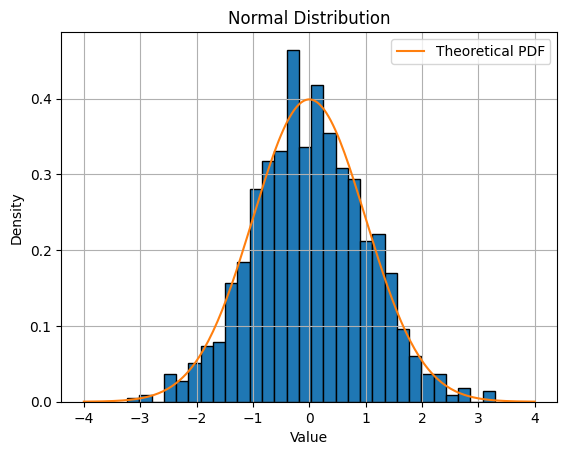

In [21]:
import matplotlib.pyplot as plt
from scipy.stats import norm
data = np.random.normal(loc = 0 , scale= 1 , size =1000)

plt.hist (data,bins=30,edgecolor='black', density=True)


x = np.linspace(-4, 4, 200)
pdf = norm.pdf(x, loc=0, scale=1)
plt.plot(x, pdf, label="Theoretical PDF")

plt.title("Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.grid(True)
plt.legend()
plt.show()




Explanation:

np.random.normal(loc=0, scale=1, size=1000) generates 1000 values following a standard normal distribution.

plt.hist(data, density=True) plots the frequency of values, normalized to form a density curve.

norm.pdf(x, loc=0, scale=1) computes the theoretical bell curve for comparison.

Plotting both together shows how closely the generated random numbers follow the actual normal distribution.

# Binomial Distribution in NumPy

The Binomial Distribution models the number of successes in a fixed number of independent trials where each trial has only two outcomes: success or failure. In NumPy, we use the numpy.random.binomial() method to generate values that follow this distribution. It is commonly used in coin flips, defect detection, surveys, and probability experiments.

Example: Here, we generate one binomial random value using 10 trials and a 0.5 probability of success.

In [1]:
import numpy as np 
x = np.random.binomial(n=10,p=0.5)
print(x)

5




Explanation: np.random.binomial(n=10, p=0.5) simulates 10 yes/no events and returns how many times success occurred.

Syntax :

$$
**
numpy.random.binomial(n, p, size=None)
**
$$

Parameters:

n: Number of trials

p: Probability of success in each trial

size: Shape of output array

Examples
Example 1: In this example, we generate 5 binomial random numbers using 10 trials and 0.5 probability.






In [2]:
arr = np.random.binomial(n=10,p=0.5,size=5)
print(arr)

[4 8 3 5 4]


Explanation:

np.random.binomial(..., size=5) returns an array of 5 simulated outcomes.

Example 2: Here, we simulate 8 trials with different success probability (p = 0.3).






In [4]:
x=np.random.binomial(8, 0.3,size=4)
print(x)


[3 2 3 3]


In [5]:
x=np.random.binomial(12,0.6,size=(2,3))
print(x)

[[8 8 8]
 [6 6 6]]


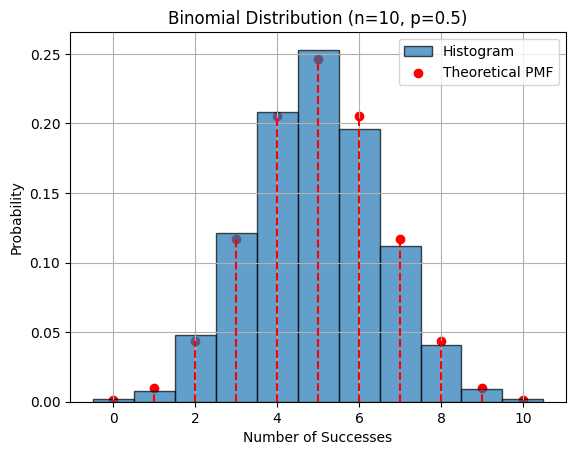

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

n = 10
p = 0.5
size = 1000

data = np.random.binomial(n, p, size)

plt.hist(data, bins=np.arange(-0.5, n+1.5, 1), density=True, edgecolor='black', alpha=0.7, label='Histogram')

x = np.arange(0, n+1)
pmf = binom.pmf(x, n, p)

plt.scatter(x, pmf, color='red', label='Theoretical PMF')
plt.vlines(x, 0, pmf, colors='red', linestyles='dashed')

plt.title("Binomial Distribution (n=10, p=0.5)")
plt.xlabel("Number of Successes")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.show()

# Poisson Distribution 

The Poisson distribution is used to model how many times an event happens within a fixed period or space, when the events occur independently at some average rate.

Simple example

Suppose a website receives an average of 5 orders per minute.

We can ask:

What is the probability that exactly 7 orders arrive in the next minute?

That's a Poisson-distribution problem.

The main parameter is:

$$ \boxed{\lambda = \text{average number of events}} $$

Here:

λ=5

In [12]:
x=np.random.poisson(lam=3)
print(x)


2


In [13]:
m=np.random.poisson(lam = 5, size=(2,3))
print(m)

[[6 3 5]
 [5 3 8]]


Visualizing the Poisson Distribution
To understand the distribution better we can visualize the generated numbers. Here is an example of plotting a histogram of random numbers generated using numpy.random.poisson.

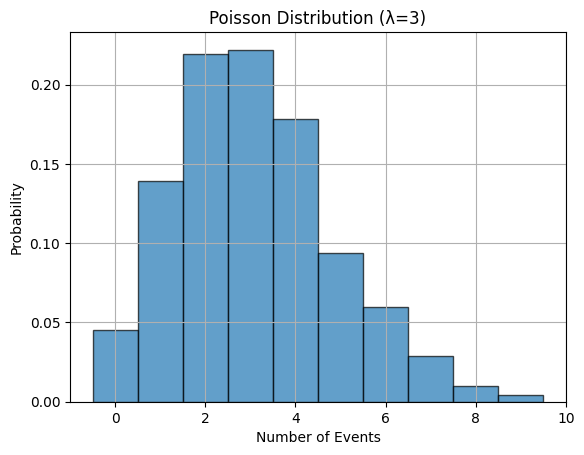

In [15]:
lam =3
data = np.random.poisson(lam, size=1000)

plt.hist(data,bins=np.arange(-0.5,max(data)+1.5,1),density=True,edgecolor='black',alpha=0.7,label='Histogram')
plt.title(f"Poisson Distribution (λ={lam})")
plt.xlabel("Number of Events")
plt.ylabel("Probability")
plt.grid(True)
plt.show()

Explanation:

np.random.poisson(lam, size=1000) generates 1000 values following the Poisson distribution.

The histogram shows how frequently each event count appears (0, 1, 2, …).

Poisson histograms usually peak near λ and decrease as the event count increases.

# Uniform Distribution in NumPy

A Uniform Distribution is used when every value in a given range has an equal probability of occurring. NumPy provides the numpy.random.uniform() method to generate such values for simulations, sampling, and numerical experiments.

Example: Here’s the example demonstrating how to generate one random value from a Uniform Distribution.


In [16]:
num = np.random.uniform()
print(num)


0.5483947701693873


Explanation: This generates a random floating-point number between 0 and 1, the default uniform range.

Syntax
numpy.random.uniform(low=0.0, high=1.0, size=None)

Parameters:

low: Lower bound of the range (inclusive).
high: Upper bound of the range (exclusive).
size: Shape of the output array.

Example 1: This example shows how to generate five random numbers between 0 and 1 multiple uniform distribution values.

In [18]:
num = np.random.uniform(10 , 20 ,size=5)
print(num)


[12.5252794  10.28859779 11.62070944 11.93550668 10.26127212]


Explanation: This creates an array vals with 5 values sampled uniformly from the interval 10 ≤ x < 20 using np.random.uniform(10, 20, size=5).

**Using NumPy Generator**

NumPy now recommends using the Generator class for random number generation instead of the legacy numpy.random functions. The Generator provides better randomness, reproducibility, and performance. You can create a Generator instance using np.random.default_rng() and then use its .uniform() method to generate uniform random numbers.

Example: Here, we generate a 2×3 matrix where each value comes from the Uniform Distribution between 1 and 5 using Generator.




In [19]:
rng = np.random.default_rng()
m=rng.uniform(1,5,size=(2,3))
print(m)


[[2.36187548 3.0726159  1.34396524]
 [3.31743027 2.57354858 4.52177809]]


Explanation: The rng.uniform(1, 5, size=(2, 3)) call generates a 2×3 array where each value is drawn uniformly from 1 ≤ x < 5.

**Visualizing the Uniform Distribution**

Visualizing the generated numbers helps in understanding their behavior. Let's see a example to plot a histogram of random numbers using numpy.random.uniform function.

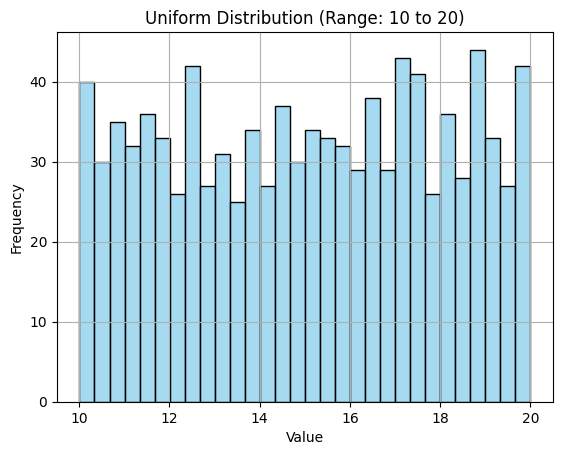

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

low =10
high = 20
size=1000

data = np.random.uniform(low, high , size)

sns.histplot(data,bins=30 , kde=False, color='skyblue', edgecolor='black')
plt.title(f"Uniform Distribution (Range: {low} to {high})")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


Explanation:

The histogram shows values scattered uniformly between low (10) and high (20).
Every number in this interval appears with similar frequency, which is the core property of a uniform distribution.
The flat pattern of bars confirms equal probability for all values in the range.

**Compute the mean, standard deviation, and variance of a given NumPy array**

 In NumPy, we can compute the mean, standard deviation, and variance of a given array along the second axis by two approaches first is by using inbuilt functions and second is by the formulas of the mean, standard deviation, and variance.

**Method 1: Using numpy.mean(), numpy.std(), numpy.var()**





In [25]:
arr=np.arange(10)
print(arr)

r1= np.mean(arr)
print("Mean of the array:", r1)

r2 = np.std(arr)
print("Standard Deviation of the array:", r2)

r3 = np.var(arr)
print("Variance of the array:", r3)



[0 1 2 3 4 5 6 7 8 9]
Mean of the array: 4.5
Standard Deviation of the array: 2.8722813232690143
Variance of the array: 8.25


# Vectorization in NumPy with Practical Examples

Vectorization in NumPy refers to applying operations on entire arrays without using explicit loops. These operations are internally optimized using fast C/C++ implementations, making numerical computations more efficient and easier to write.

Why Vectorization Matters?
Vectorization is important because it:

Improves Performance: Eliminates Python-level loops and leverages fast low-level implementations.

Produces Cleaner Code: Fewer lines, easier to maintain.

Scales Better: Can efficiently handle large scientific data and machine learning workloads.

Examples of Vectorization

Example 1: Add a number to each element

Performs element-wise addition across the entire array without using loops, making the operation fast and efficient.






In [27]:
a1 = np.array([1, 2, 3, 4, 5])

num = 2

res = a1 +num
print(res)


[3 4 5 6 7]


In [28]:
a1= np.array([1, 2, 3])
a2 = np.array([4, 5, 6])

res = a1+a2
print(res)
    


[5 7 9]


In [29]:
a1= np.array([1, 2, 3, 4, 5])
res = a1*2
print(res)
    

[ 2  4  6  8 10]


In [30]:
a1 = np.array([10 , 20 , 30])
res = a1 > 15
print(res)

[False  True  True]


**Matrix operations using Vectorization**

NumPy supports vectorized matrix operations like dot products and matrix multiplications using functions such as np.dot and @.

In [31]:
a1= np.array([[1,2] , [3,4]])
a2 = np.array([[5,6] , [7,8]])
res = np.dot(a1 , a2)
print(res)

[[19 22]
 [43 50]]


Explanation: Performs matrix multiplication (dot product) between a1 and a2.

**Example 6: Applying Custom Functions Using np.vectorize()**

np.vectorize applies a custom function element-wise to a NumPy array, e.g., computing x² + 2x + 1 for each element efficiently.

In [33]:
a1= np.array([1,2,3,4])
vec = np.vectorize(lambda x: x**2 +2*x +1)
res = vec(a1)
print(res)

[ 4  9 16 25]


Explanation: Performs the operation x**2+2*x+1 element-wise on the array a1 using NumPy’s vectorized arithmetic.



In [35]:
a1 = np.array([1,2,3])
r1 = a1.sum()
r2=np.mean(a1)
print(r1)
print(r2)

6
2.0


Explanation: Calculates the sum (r1) and mean (r2) of all elements in the array a1 using NumPy’s vectorized aggregation functions.

# Performance Comparison: Loop vs. Vectorization
When working with large datasets, performance matters. In Pandas and NumPy, vectorization is almost always faster than writing manual Python loops. This is because vectorized operations are executed in optimized C code internally, while Python loops run line-by-line in Python (much slower).

Example: We will create a large NumPy array and apply the same operation (multiply each element by 2) using both:

For Loop (Python-level)
Vectorized Operation (NumPy-level)

In [42]:
import time

arr= np.arange(1_000_000)

#loops
t1 = time.time()
loop_res = [x*2 for x in arr]
t2 = time.time()

#vectorize 
t3 = time.time()
vec_res = arr * 2
t4 = time.time()

print("loop Time: " , t2-t1)
print("vectorized Time :" , t4-t3  )



loop Time:  0.5035483837127686
vectorized Time : 0.004999399185180664


Explanation:

arr = np.arange(1_000_000): Creates a NumPy array with 1 million numbers.

Loop method: [x * 2 for x in arr] processes each element one-by-one in Python, which is slow and t2 - t1 measures how long the loop took.

Vectorized method: arr * 2 uses fast optimized C-level operations inside NumPy and t4 - t3 measures how fast vectorization is.

Vectorization is significantly faster because operations happen in optimized low-level code instead of Python's slow element-by-element loop.

# sparse matrix

A sparse matrix is a matrix where most values are 0.

A = np.array([
    [0, 0, 0, 5],
    [0, 0, 0, 0],
    [0, 3, 0, 0],
    [0, 0, 0, 0]
])
Here, only 2 out of 16 values are non-zero.

So:

Dense matrix → stores every value, including zeros.

Sparse matrix → mainly stores the non-zero values and their positions.
Why does this matter?

Imagine a matrix with:

1,000,000 × 1,000,000 = 1 trillion elements

If 99.99% are zero, storing all those zeros wastes enormous memory.

A sparse representation can store only the useful values.

**2. Simple real-world example**

Suppose we have 5 documents and 6 words:

|      | AI | Python | Data | Football | Model | Java |
| ---- | -: | -----: | ---: | -------: | ----: | ---: |
| Doc1 |  1 |      1 |    0 |        0 |     1 |    0 |
| Doc2 |  0 |      0 |    1 |        0 |     0 |    0 |
| Doc3 |  1 |      0 |    0 |        0 |     1 |    0 |
| Doc4 |  0 |      0 |    0 |        1 |     0 |    0 |
| Doc5 |  0 |      1 |    0 |        0 |     0 |    1 |

Most entries are zero.

This is exactly the kind of situation where sparse matrices are useful in NLP.

**3. Creating a sparse matrix**

Sparse matrices aren't primarily handled with basic NumPy. In Python, you'll commonly use SciPy.

In [44]:
from scipy.sparse import csr_matrix

A = csr_matrix([
    [0,0,5],
    [0,0,0],
    [3,0,0]
])
print(A)



  (0, 2)	5
  (2, 0)	3


This means:

position (0,2) contains 5
position (2,0) contains 3

The zeros don't need to be explicitly stored

**4. What is CSR?**

You'll frequently encounter:

CSR = Compressed Sparse Row

It's one of the most commonly used sparse matrix formats.

Think of CSR as:

"Store the non-zero values efficiently row by row."

You don't need to memorize the internal CSR algorithm right now.

Just remember:

CSR → efficient representation of sparse matrices, especially for row-based operations.

5. Dense → Sparse

You can convert a normal NumPy matrix

In [46]:
from scipy.sparse import csr_matrix

A = np.array([
    [0,0,5],
    [0,0,0],
    [3,0,0]
])
s = csr_matrix(A)
print(s)

A_dense = s.toarray()
print(A_dense)


  (0, 2)	5
  (2, 0)	3
[[0 0 5]
 [0 0 0]
 [3 0 0]]


# Image Processing with SciPy and NumPy in Python

Image processing is used in areas like computer vision and medical imaging, focusing on enhancing and analyzing digital images. In Python, NumPy treats images as arrays for efficient pixel-level operations, while SciPy’s ndimage module provides tools for filtering and transformations, enabling fast and lightweight processing.

Installation
Ensure you have the required libraries installed:

pip install numpy scipy matplotlib imageio scikit-image

NumPy: Handles arrays and numerical computations.

SciPy: Adds advanced scientific and mathematical functions.

Matplotlib: Creates plots and visualizations.

ImageIO: Reads and writes image files.

scikit-image: Provides tools for image processing and analysis.


**Opening and Displaying Image**

To begin any image processing task, the first step is to load and visualize the image. We'll use imageio.v3 to read an image and matplotlib to display it.


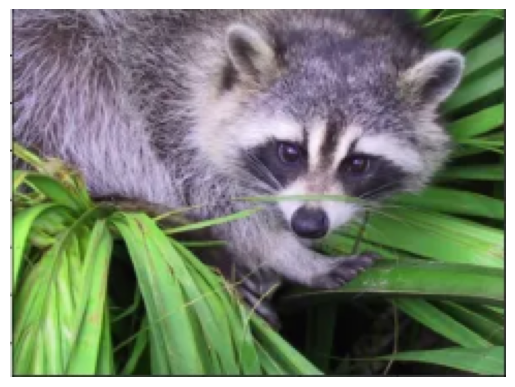

In [56]:
import imageio.v3 as iio
import matplotlib.pyplot as plt

img = iio.imread("racoon.png")
plt.imshow(img)
plt.axis('off')
plt.show()




**Explanation:**

iio.imread(): loads the image into a NumPy array.

plt.imshow(): visualizes it.

plt.axis('off'): hides axes for a cleaner look.

**Creating NumPy array from Image**

An image is essentially a multi-dimensional NumPy array. Knowing its shape and data type is important for applying filters and transformations.

In [58]:
import imageio.v3 as iio

img = iio.imread("racoon.png")
print("shape: " , img.shape)
print("Data type: " , img.dtype)

shape:  (178, 240, 4)
Data type:  uint8


Explanation: Shape helps understand the image layout (e.g., 266x341x3 for RGB). Data type (usually uint8) shows pixel value range (0-255).

**Creating RAW file**

A .raw file stores raw binary data from an image sensor or matrix. It's useful when dealing with uncompressed data in image pipelines

In [61]:
import imageio.v3 as iio
import numpy as np

img = iio.imread("racoon.png")
img.tofile("racoon.raw")


In [64]:
import imageio.v3 as iio
import numpy as np

orig = iio.imread("racoon.png")
h,w,c = orig.shape

flat = np.fromfile('racoon.raw' ,dtype = np.uint8)
img = flat.reshape((h,w,c))
print(img.shape)

(178, 240, 4)


Explanation: fromfile() reads binary data and the array must be reshaped manually if you want to visualize it (e.g., reshape to original height × width × channels).

**Getting Statistical Information**

Understanding the min, max and average pixel intensity gives insight into brightness, contrast and histogram distribution of the image.

In [65]:
import imageio.v3 as iio
import numpy as np

img = iio.imread("racoon.png")
print("Max: " , img.max())
print("Min:", img.min())
print("Mean:", img.mean())


Max:  255
Min: 0
Mean: 145.67792602996255


Explanation: Max and min values indicate contrast and Mean gives an overall idea of brightness.

 **Cropping the Image**
 
Cropping helps focus on a particular region of interest (ROI) in an image by slicing the NumPy array.

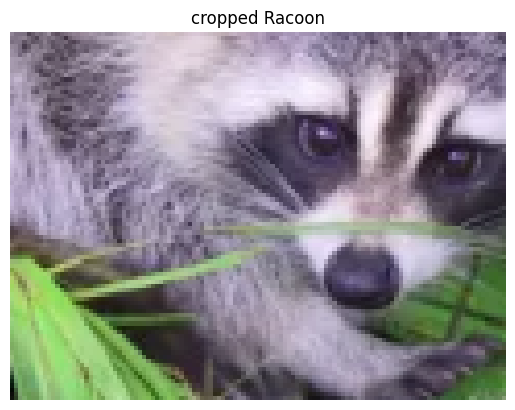

In [70]:
img = iio.imread("racoon.png")
h , w ,_ = img.shape

crop = img[h//4: 3*h//4 , w//4 : 3*w//4 ]

plt.imshow(crop)
plt.axis('off')
plt.title('cropped Racoon')
plt.show()

Explanation:

img.shape: gives image dimensions (height x, width y, channels _).

img[h//4 : 3*h//4, w//4 : 3*w//4]: selects a central region using slicing.

plt.imshow(): visualizes the cropped section.

**Flipping Image (Vertical)**

Flipping an image (up-down or left-right) is a common data augmentation technique in image preprocessing.

Explanation: np.flipud() flips the image along the vertical axis.



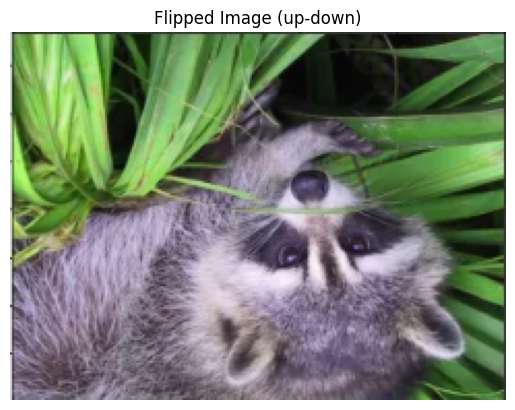

In [72]:
flipped = np.flipud(img)

plt.imshow(flipped)
plt.axis('off')
plt.title("Flipped Image (up-down)")
plt.show()

**Filtering images**

Filtering is a fundamental technique in image processing used to enhance or suppress certain features. It helps in tasks like smoothing, sharpening and edge detection.

**1. Gaussian Blur**
Blurring helps reduce image noise and details using a Gaussian kernel. It’s useful in preprocessing steps like edge detection or thresholding.

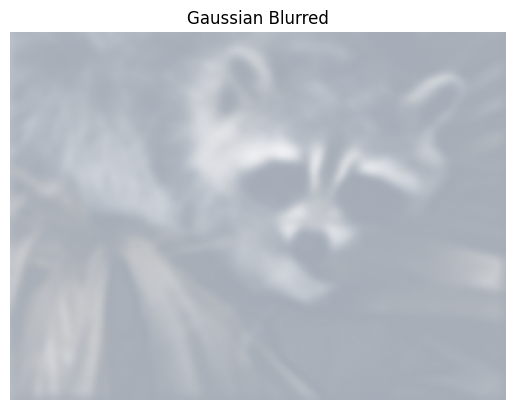

In [ ]:
from scipy.ndimage import gaussian_filter
import imageio.v3 as iio
import matplotlib.pyplot as plt
import numpy as np

img = iio.imread("racoon.png")
blurred = gaussian_filter(img, sigma=5)

plt.imshow(blurred.astype(np.uint8))
plt.axis('off')
plt.title("Gaussian Blurred")
plt.show()

Explanation: gaussian_filter(img, sigma=5) smooths the image using a Gaussian kernel. sigma controls the intensity of blur and converts to uint8 before display to ensure proper color rendering.

**2. Sharpening Image (Unsharp Masking)**

Sharpening increases contrast between edges to enhance details and clarity. Unsharp masking subtracts a blurred version from the original.

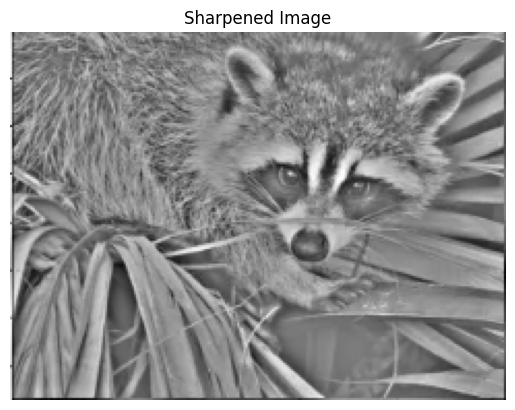

In [83]:
from skimage.color import rgb2gray, rgba2rgb
from scipy.ndimage import gaussian_filter
import imageio.v3 as iio
import matplotlib.pyplot as plt
import numpy as np

img = iio.imread("racoon.png")
if img.shape[-1] == 4:
    img = rgba2rgb(img)

gray = rgb2gray(img).astype(float)
blur = gaussian_filter(gray, 5)
alpha = 30
sharp = gray + alpha * (gray - gaussian_filter(blur, 1))

plt.imshow(sharp, cmap='gray')
plt.axis('off')
plt.title("Sharpened Image")
plt.show()